# Sprint 2 – Dataset Readiness  
## Task 4: Complete Expanded Dataset Cleaning, Validation, and Merge


### Main outputs
- `cleaned_merged_dataset.zip`
- `updated_species_manifest.csv`
- `coverage_report.csv`
- `removed_invalid_data_log.csv`
- `duplicate_report.csv`
- `final_structure_summary.txt`


## Step 1: Upload the existing and expanded dataset zips

Upload:
1. `sprint2_existing_engine_dataset.zip`
2. `sprint2_expanded_dataset_raw_big.zip`


In [3]:
from google.colab import files
uploaded = files.upload()
print("Uploaded files:")
for name in uploaded.keys():
    print("-", name)

Saving sprint2_expanded_dataset_raw_big.zip to sprint2_expanded_dataset_raw_big (1).zip
Saving sprint2_existing_engine_dataset.zip to sprint2_existing_engine_dataset (1).zip
Uploaded files:
- sprint2_expanded_dataset_raw_big (1).zip
- sprint2_existing_engine_dataset (1).zip


## Step 2: Import required libraries and create working folders

These libraries handle file extraction, dataset scanning, validation, duplicate detection, report creation, and final packaging.


In [4]:
import os
import re
import csv
import json
import wave
import shutil
import zipfile
import hashlib
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

WORK_DIR = Path("/content/sprint2_dataset_readiness")
OLD_EXTRACT_DIR = WORK_DIR / "old_dataset_extracted"
EXPANDED_EXTRACT_DIR = WORK_DIR / "expanded_dataset_extracted"
MERGED_DIR = WORK_DIR / "cleaned_merged_dataset"
REPORT_DIR = WORK_DIR / "reports"

for folder in [OLD_EXTRACT_DIR, EXPANDED_EXTRACT_DIR, MERGED_DIR, REPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Working directory:", WORK_DIR)

Working directory: /content/sprint2_dataset_readiness


## Step 3: Extract uploaded zip files

The existing dataset and expanded dataset are extracted into separate folders so they can be compared before merging.


In [5]:
zip_files = [Path(name) for name in uploaded.keys() if name.lower().endswith(".zip")]

if len(zip_files) < 2:
    raise ValueError("Please upload both old/existing dataset zip and expanded dataset zip.")

old_zip = None
expanded_zip = None

for z in zip_files:
    lower = z.name.lower()
    if "existing" in lower or "old" in lower:
        old_zip = z
    elif "expanded" in lower or "raw" in lower:
        expanded_zip = z

# Fallback if names are different
if old_zip is None:
    old_zip = zip_files[0]
if expanded_zip is None:
    expanded_zip = zip_files[1]

print("Existing dataset zip:", old_zip)
print("Expanded dataset zip:", expanded_zip)

with zipfile.ZipFile(old_zip, "r") as z:
    z.extractall(OLD_EXTRACT_DIR)

with zipfile.ZipFile(expanded_zip, "r") as z:
    z.extractall(EXPANDED_EXTRACT_DIR)

print("Extraction completed.")

Existing dataset zip: sprint2_existing_engine_dataset (1).zip
Expanded dataset zip: sprint2_expanded_dataset_raw_big (1).zip
Extraction completed.


## Step 4: Detect the actual dataset root folders
.


In [6]:
AUDIO_EXTENSIONS = {".wav", ".mp3", ".flac", ".ogg", ".m4a"}

def count_audio_files(folder: Path) -> int:
    count = 0
    for file in folder.rglob("*"):
        if file.is_file() and file.suffix.lower() in AUDIO_EXTENSIONS:
            count += 1
    return count

def detect_dataset_root(extracted_dir: Path) -> Path:
    candidates = [extracted_dir] + [p for p in extracted_dir.rglob("*") if p.is_dir()]
    candidates = sorted(candidates, key=lambda p: count_audio_files(p), reverse=True)
    return candidates[0]

old_root = detect_dataset_root(OLD_EXTRACT_DIR)
expanded_root = detect_dataset_root(EXPANDED_EXTRACT_DIR)

print("Old dataset root:", old_root)
print("Expanded dataset root:", expanded_root)
print("Old audio files:", count_audio_files(old_root))
print("Expanded audio files:", count_audio_files(expanded_root))

Old dataset root: /content/sprint2_dataset_readiness/old_dataset_extracted
Expanded dataset root: /content/sprint2_dataset_readiness/expanded_dataset_extracted
Old audio files: 360
Expanded audio files: 913


## Step 5: Define species naming rules

This step standardises inconsistent class names.  
For example, spaces, hyphens, capital letters, and trailing spaces are converted into a clean lower-case underscore format.


In [7]:
def standardise_species_name(name: str) -> str:
    # Convert names like "Rainbow Lorikeet ", "rainbow-lorikeet", and "Rainbow_Lorikeet"
    # into "rainbow_lorikeet".
    name = name.strip().lower()
    name = re.sub(r"[^a-z0-9]+", "_", name)
    name = re.sub(r"_+", "_", name)
    return name.strip("_")

examples = ["Sulphur Crested Cockatoo", "laughing-kookaburra", "Rainbow_Lorikeet "]
for e in examples:
    print(e, "->", standardise_species_name(e))

Sulphur Crested Cockatoo -> sulphur_crested_cockatoo
laughing-kookaburra -> laughing_kookaburra
Rainbow_Lorikeet  -> rainbow_lorikeet


## Step 6: Build a file manifest for each dataset

The manifest records what is actually present on disk.  
It includes species name, standardised species name, file path, extension, and file size.


In [8]:
def build_manifest(dataset_root: Path, dataset_label: str) -> pd.DataFrame:
    rows = []
    for file in dataset_root.rglob("*"):
        if not file.is_file():
            continue

        relative_path = file.relative_to(dataset_root)
        parts = relative_path.parts
        raw_species = parts[0] if len(parts) > 1 else "unassigned"
        standard_species = standardise_species_name(raw_species)

        rows.append({
            "dataset": dataset_label,
            "raw_species": raw_species,
            "species": standard_species,
            "file_name": file.name,
            "relative_path": str(relative_path).replace("\\", "/"),
            "absolute_path": str(file),
            "extension": file.suffix.lower(),
            "file_size_bytes": file.stat().st_size
        })
    return pd.DataFrame(rows)

old_manifest = build_manifest(old_root, "existing")
expanded_manifest = build_manifest(expanded_root, "expanded")

print("Old manifest rows:", len(old_manifest))
print("Expanded manifest rows:", len(expanded_manifest))
expanded_manifest.head()

Old manifest rows: 361
Expanded manifest rows: 924


,dataset,raw_species,species,file_name,relative_path,absolute_path,extension,file_size_bytes
0,expanded,expanded_dataset_raw,expanded_dataset_raw,raw_expanded_manifest.csv,expanded_dataset_raw/raw_expanded_manifest.csv,/content/sprint2_dataset_readiness/expanded_da...,.csv,95119
1,expanded,expanded_dataset_raw,expanded_dataset_raw,Sulphur_Crested_Cockatoo_exp_012.wav,expanded_dataset_raw/Sulphur Crested Cockatoo/...,/content/sprint2_dataset_readiness/expanded_da...,.wav,149092
2,expanded,expanded_dataset_raw,expanded_dataset_raw,Sulphur_Crested_Cockatoo_exp_022.wav,expanded_dataset_raw/Sulphur Crested Cockatoo/...,/content/sprint2_dataset_readiness/expanded_da...,.wav,41674
3,expanded,expanded_dataset_raw,expanded_dataset_raw,Sulphur_Crested_Cockatoo_exp_003.wav,expanded_dataset_raw/Sulphur Crested Cockatoo/...,/content/sprint2_dataset_readiness/expanded_da...,.wav,40754
4,expanded,expanded_dataset_raw,expanded_dataset_raw,Sulphur_Crested_Cockatoo_exp_025.wav,expanded_dataset_raw/Sulphur Crested Cockatoo/...,/content/sprint2_dataset_readiness/expanded_da...,.wav,56154


## Step 7: Validate file type, file size, and audio readability

This step checks:
- whether the file is an accepted audio format  
- whether the file is empty  
- whether the audio can be opened  
- duration, sample rate, and number of channels for `.wav` files  


In [9]:
def inspect_audio_file(path: str, extension: str):
    result = {
        "is_audio_extension": extension in AUDIO_EXTENSIONS,
        "is_empty": False,
        "is_readable_audio": False,
        "duration_seconds": None,
        "sample_rate": None,
        "channels": None,
        "validation_issue": ""
    }

    file_path = Path(path)

    if file_path.stat().st_size == 0:
        result["is_empty"] = True
        result["validation_issue"] = "empty_file"
        return result

    if extension not in AUDIO_EXTENSIONS:
        result["validation_issue"] = "invalid_extension"
        return result

    # This workbook uses wave for reliable built-in validation of wav files.
    # Other audio formats are kept if they are non-empty and have a valid extension.
    if extension == ".wav":
        try:
            with wave.open(str(file_path), "rb") as wf:
                frames = wf.getnframes()
                sample_rate = wf.getframerate()
                channels = wf.getnchannels()
                duration = frames / float(sample_rate) if sample_rate else 0

            result["is_readable_audio"] = True
            result["duration_seconds"] = round(duration, 4)
            result["sample_rate"] = sample_rate
            result["channels"] = channels

            if duration < 1:
                result["validation_issue"] = "duration_too_short"
            elif duration > 6:
                result["validation_issue"] = "duration_too_long"
            else:
                result["validation_issue"] = ""

        except Exception:
            result["validation_issue"] = "corrupt_or_unreadable_audio"
    else:
        result["is_readable_audio"] = True
        result["validation_issue"] = ""

    return result

def apply_validation(df: pd.DataFrame) -> pd.DataFrame:
    validation_rows = []
    for _, row in df.iterrows():
        validation_rows.append(inspect_audio_file(row["absolute_path"], row["extension"]))
    validation_df = pd.DataFrame(validation_rows)
    return pd.concat([df.reset_index(drop=True), validation_df], axis=1)

old_validated = apply_validation(old_manifest)
expanded_validated = apply_validation(expanded_manifest)

expanded_validated["validation_issue"].value_counts(dropna=False)

,count
validation_issue,
,885
invalid_extension,11
empty_file,10
corrupt_or_unreadable_audio,10
duration_too_short,4
duration_too_long,4


## Step 8: Generate file hashes for duplicate detection

Hashing creates a unique fingerprint for each file.  
If two files have the same hash, their content is exactly the same even if the filenames are different.


In [10]:
def file_hash(path: str, chunk_size: int = 1024 * 1024) -> str:
    md5 = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            md5.update(chunk)
    return md5.hexdigest()

def add_hashes(df: pd.DataFrame) -> pd.DataFrame:
    hashes = []
    for _, row in df.iterrows():
        if row["validation_issue"] in ["empty_file", "invalid_extension", "corrupt_or_unreadable_audio"]:
            hashes.append(None)
        else:
            hashes.append(file_hash(row["absolute_path"]))
    df = df.copy()
    df["file_hash"] = hashes
    return df

old_validated = add_hashes(old_validated)
expanded_validated = add_hashes(expanded_validated)

print("Hashing completed.")

Hashing completed.


## Step 9: Detect duplicates across existing and expanded datasets

Duplicates are identified using file hashes.  
The existing dataset is treated as the reference, and duplicate expanded files are removed from the final merge.


In [11]:
combined = pd.concat([old_validated, expanded_validated], ignore_index=True)

valid_for_duplicate_check = combined[
    combined["file_hash"].notna()
].copy()

valid_for_duplicate_check["duplicate_count"] = valid_for_duplicate_check.groupby("file_hash")["file_hash"].transform("count")
duplicates = valid_for_duplicate_check[valid_for_duplicate_check["duplicate_count"] > 1].copy()

# Mark files as duplicate if their hash already appeared earlier.
combined["is_duplicate"] = False
seen_hashes = set()

for idx, row in combined.iterrows():
    h = row["file_hash"]
    if pd.isna(h):
        continue
    if h in seen_hashes:
        combined.at[idx, "is_duplicate"] = True
    else:
        seen_hashes.add(h)

duplicate_report = combined[combined["is_duplicate"] == True].copy()
print("Duplicate files detected:", len(duplicate_report))
duplicate_report[["dataset", "species", "file_name", "relative_path", "file_hash"]].head()

Duplicate files detected: 45


,dataset,species,file_name,relative_path,file_hash
691,expanded,expanded_dataset_raw,australian_magpie_exp_018.wav,expanded_dataset_raw/australian_magpie/austral...,701b179a148abb756bc0ecf2fe8dbc80
694,expanded,expanded_dataset_raw,australian_magpie_exp_008.wav,expanded_dataset_raw/australian_magpie/austral...,a348e139b94cb929616855ebb5d37710
695,expanded,expanded_dataset_raw,australian_magpie_exp_011.wav,expanded_dataset_raw/australian_magpie/austral...,9c4525dd4a58536e26acbb53510b9767
697,expanded,expanded_dataset_raw,australian_magpie_exp_019.wav,expanded_dataset_raw/australian_magpie/austral...,a5b7d406d1e9a3f07f57e93ebe936b88
698,expanded,expanded_dataset_raw,australian_magpie_exp_010.wav,expanded_dataset_raw/australian_magpie/austral...,a6b8de29e086a7ba8a9056b6e9231e3d


## Step 10: Select files that are clean and ready to merge

A file is kept if:
- it has a valid audio extension  
- it is not empty  
- it is readable  
- it is not a duplicate  
- it does not have an unacceptable duration issue  


In [12]:
invalid_issues = {
    "empty_file",
    "invalid_extension",
    "corrupt_or_unreadable_audio",
    "duration_too_short",
    "duration_too_long"
}

combined["remove_reason"] = ""

combined.loc[combined["validation_issue"].isin(invalid_issues), "remove_reason"] = combined["validation_issue"]
combined.loc[combined["is_duplicate"], "remove_reason"] = "duplicate_file"

clean_files = combined[combined["remove_reason"] == ""].copy()
removed_files = combined[combined["remove_reason"] != ""].copy()

print("Clean files selected:", len(clean_files))
print("Removed files:", len(removed_files))
removed_files["remove_reason"].value_counts()

Clean files selected: 1200
Removed files: 85


,count
remove_reason,
duplicate_file,45
invalid_extension,12
empty_file,10
corrupt_or_unreadable_audio,10
duration_too_short,4
duration_too_long,4


## Step 11: Merge clean files into Engine-compatible folder structure

The final structure uses one folder per species/class.  
Each cleaned file is copied into the standardised species folder.


In [13]:
if MERGED_DIR.exists():
    shutil.rmtree(MERGED_DIR)
MERGED_DIR.mkdir(parents=True, exist_ok=True)

final_rows = []

for _, row in clean_files.iterrows():
    species_folder = MERGED_DIR / row["species"]
    species_folder.mkdir(parents=True, exist_ok=True)

    # Create a safe unique filename to avoid collisions.
    source_prefix = "old" if row["dataset"] == "existing" else "exp"
    safe_name = f"{source_prefix}_{row['file_hash'][:10]}_{row['file_name']}"
    destination = species_folder / safe_name

    shutil.copy2(row["absolute_path"], destination)

    final_rows.append({
        "species": row["species"],
        "file_name": safe_name,
        "relative_path": str(destination.relative_to(MERGED_DIR)).replace("\\", "/"),
        "source_dataset": row["dataset"],
        "duration_seconds": row["duration_seconds"],
        "sample_rate": row["sample_rate"],
        "channels": row["channels"],
        "file_hash": row["file_hash"]
    })

updated_species_manifest = pd.DataFrame(final_rows)
print("Merged dataset created at:", MERGED_DIR)
print("Final manifest rows:", len(updated_species_manifest))
updated_species_manifest.head()

Merged dataset created at: /content/sprint2_dataset_readiness/cleaned_merged_dataset
Final manifest rows: 1200


,species,file_name,relative_path,source_dataset,duration_seconds,sample_rate,channels,file_hash
0,existing_engine_dataset,old_adff50c8f3_brown_thornbill_old_010.wav,existing_engine_dataset/old_adff50c8f3_brown_t...,existing,4.0047,16000.0,1.0,adff50c8f37c9e35f7d98906c6959834
1,existing_engine_dataset,old_e2e16b7064_brown_thornbill_old_003.wav,existing_engine_dataset/old_e2e16b7064_brown_t...,existing,3.5556,16000.0,1.0,e2e16b70643d7280c2dc1efd34826870
2,existing_engine_dataset,old_b24f03046c_brown_thornbill_old_007.wav,existing_engine_dataset/old_b24f03046c_brown_t...,existing,1.6554,16000.0,1.0,b24f03046c955664dbe931e3ffe6831c
3,existing_engine_dataset,old_9bbfc03fac_brown_thornbill_old_015.wav,existing_engine_dataset/old_9bbfc03fac_brown_t...,existing,3.7898,16000.0,1.0,9bbfc03facb16b174d5e40df23290634
4,existing_engine_dataset,old_dbc8023faa_brown_thornbill_old_014.wav,existing_engine_dataset/old_dbc8023faa_brown_t...,existing,3.1959,16000.0,1.0,dbc8023faa764131fadca5bcd6120b78


## Step 12: Create coverage report

The coverage report compares old dataset coverage, expanded dataset coverage, and final merged dataset coverage by species.


In [14]:
old_coverage = old_validated[
    old_validated["validation_issue"] == ""
].groupby("species").size().rename("old_valid_file_count")

expanded_coverage = expanded_validated[
    expanded_validated["validation_issue"] == ""
].groupby("species").size().rename("expanded_valid_file_count")

final_coverage = updated_species_manifest.groupby("species").size().rename("final_merged_file_count")

coverage_report = pd.concat([old_coverage, expanded_coverage, final_coverage], axis=1).fillna(0).astype(int).reset_index()
coverage_report["coverage_change_vs_old"] = coverage_report["final_merged_file_count"] - coverage_report["old_valid_file_count"]
coverage_report = coverage_report.sort_values("final_merged_file_count", ascending=False)

coverage_report.head(15)

,species,old_valid_file_count,expanded_valid_file_count,final_merged_file_count,coverage_change_vs_old
1,expanded_dataset_raw,0,885,840,840
0,existing_engine_dataset,360,0,360,0


## Step 13: Visualise coverage changes

This chart shows the species with the highest final file counts after cleaning and merging.


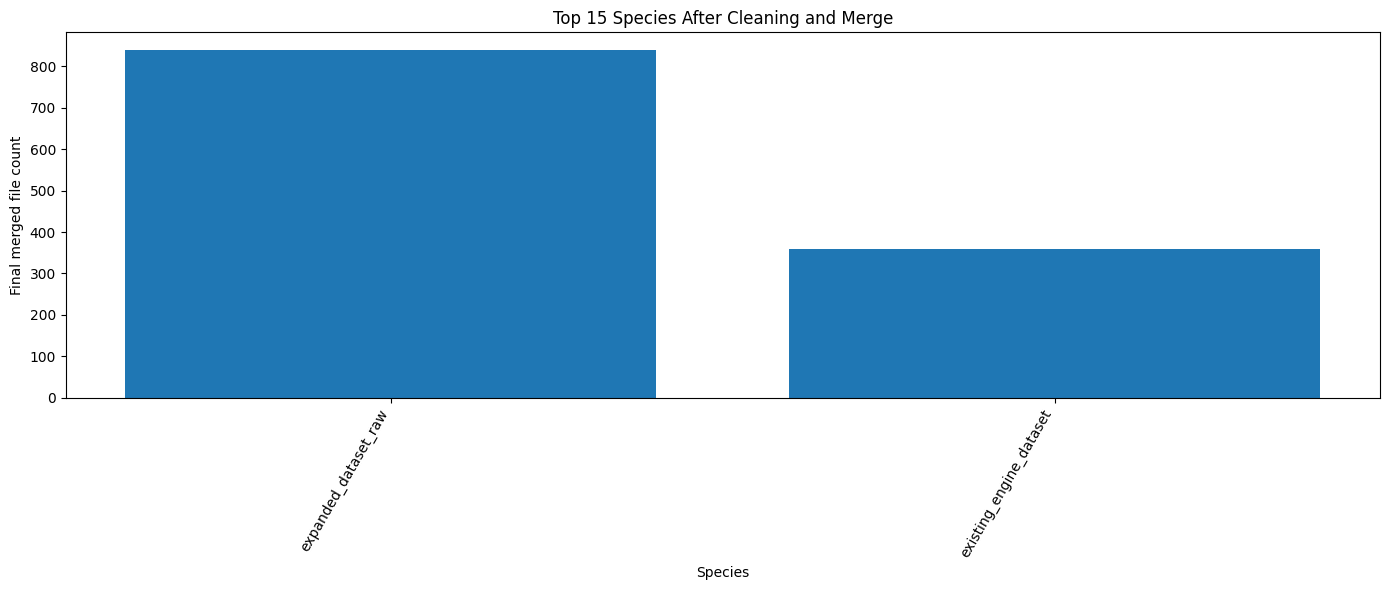

In [15]:
top_15 = coverage_report.head(15)

plt.figure(figsize=(14, 6))
plt.bar(top_15["species"], top_15["final_merged_file_count"])
plt.title("Top 15 Species After Cleaning and Merge")
plt.xlabel("Species")
plt.ylabel("Final merged file count")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

## Step 14: Save required deliverables and reports

This step exports:
- updated manifest  
- coverage report  
- removed/invalid data log  
- duplicate report  
- summary statistics  
- final structure documentation  


In [16]:
updated_species_manifest_path = REPORT_DIR / "updated_species_manifest.csv"
coverage_report_path = REPORT_DIR / "coverage_report.csv"
removed_log_path = REPORT_DIR / "removed_invalid_data_log.csv"
duplicate_report_path = REPORT_DIR / "duplicate_report.csv"
summary_statistics_path = REPORT_DIR / "summary_statistics.csv"
structure_summary_path = REPORT_DIR / "final_structure_summary.txt"

updated_species_manifest.to_csv(updated_species_manifest_path, index=False)
coverage_report.to_csv(coverage_report_path, index=False)

removed_files[[
    "dataset", "raw_species", "species", "file_name", "relative_path",
    "extension", "file_size_bytes", "duration_seconds", "remove_reason"
]].to_csv(removed_log_path, index=False)

duplicate_report[[
    "dataset", "raw_species", "species", "file_name", "relative_path", "file_hash"
]].to_csv(duplicate_report_path, index=False)

summary = {
    "old_valid_files": int((old_validated["validation_issue"] == "").sum()),
    "expanded_valid_files_before_duplicate_removal": int((expanded_validated["validation_issue"] == "").sum()),
    "final_merged_files": int(len(updated_species_manifest)),
    "old_species_count": int(old_validated[old_validated["validation_issue"] == ""]["species"].nunique()),
    "expanded_species_count": int(expanded_validated[expanded_validated["validation_issue"] == ""]["species"].nunique()),
    "final_species_count": int(updated_species_manifest["species"].nunique()),
    "removed_files": int(len(removed_files)),
    "duplicate_files_removed": int((removed_files["remove_reason"] == "duplicate_file").sum())
}

pd.DataFrame([summary]).to_csv(summary_statistics_path, index=False)

with open(structure_summary_path, "w") as f:
    f.write("Sprint 2 Task 4: Dataset Readiness\n")
    f.write("Final directory structure:\n")
    f.write("cleaned_merged_dataset/\n")
    f.write("  species_name/\n")
    f.write("    audio_files.wav\n\n")
    f.write("Summary statistics:\n")
    for key, value in summary.items():
        f.write(f"- {key}: {value}\n")
    f.write("\nReports generated:\n")
    for report in [updated_species_manifest_path, coverage_report_path, removed_log_path, duplicate_report_path, summary_statistics_path]:
        f.write(f"- {report.name}\n")

print("Reports saved in:", REPORT_DIR)
print(summary)

Reports saved in: /content/sprint2_dataset_readiness/reports
{'old_valid_files': 360, 'expanded_valid_files_before_duplicate_removal': 885, 'final_merged_files': 1200, 'old_species_count': 1, 'expanded_species_count': 1, 'final_species_count': 2, 'removed_files': 85, 'duplicate_files_removed': 45}


## Step 15: Package the cleaned merged dataset

The final dataset package is zipped so it can be shared or used by the Engine pipeline.


In [17]:
final_zip_path = WORK_DIR / "cleaned_merged_dataset.zip"
reports_zip_path = WORK_DIR / "dataset_readiness_reports.zip"

def zip_folder(source_folder: Path, output_zip: Path):
    if output_zip.exists():
        output_zip.unlink()
    with zipfile.ZipFile(output_zip, "w", zipfile.ZIP_DEFLATED) as z:
        for file in source_folder.rglob("*"):
            if file.is_file():
                z.write(file, file.relative_to(source_folder.parent))

zip_folder(MERGED_DIR, final_zip_path)
zip_folder(REPORT_DIR, reports_zip_path)

print("Created:", final_zip_path)
print("Created:", reports_zip_path)

Created: /content/sprint2_dataset_readiness/cleaned_merged_dataset.zip
Created: /content/sprint2_dataset_readiness/dataset_readiness_reports.zip


## Step 16: Download deliverables from Colab

Download the final dataset and reports.


In [18]:
from google.colab import files

files.download(str(final_zip_path))
files.download(str(reports_zip_path))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>